In [5]:
import torch 
from tqdm import tqdm
import warnings
from sklearn.metrics import classification_report
warnings.filterwarnings("ignore")
import glob
from collections import OrderedDict  
from ReportPretraining import ReportClassification
from src.layers.transformer.lightcurve import LightCurveTransformer
from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY

In [16]:
import matplotlib.pyplot as plt
test_1 = ReportClassification(
    path_to_training_dir='/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_baseline_with__MLP_1E_trans/',
    path_to_dataset= 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5',
    #path_to_dataset= '/home/mdelafuente/ZTF_SSL_Dataset/data/H5_FILES/ztf_ff_raw/h5_dataset/ztf_ff_raw.h5',
    #path_to_dataset= '/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5',
    model_class = LightCurveTransformer,
    custom_parse_key_str= '',
    model_type = 'lc',
    taxonomy = ZTF_TAXONOMY, #ELASTICC_TAXONOMY,
    device = 'cuda:2',
    seed = 0,
    figsize = (10,10),
    batch_size=256, 
    umap_args={"n_neighbors": 15, "min_dist": 0.05, "metric": "euclidean"},
    marker_size = 6)


['/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_baseline_with__MLP_1E_trans/classifier_ckpt_step=3871.ckpt']
using checkpoint 3871.ckpt


In [17]:
dataset  ='validation'

LC
<KeysViewHDF5 ['SNID', 'extracted_feat_1024', 'extracted_feat_128', 'extracted_feat_16', 'extracted_feat_2048', 'extracted_feat_256', 'extracted_feat_32', 'extracted_feat_512', 'extracted_feat_64', 'flux', 'flux_err', 'labels', 'mask', 'mask_detection', 'mask_photometry', 'metadata_feat', 'test', 'time', 'time_detection', 'time_photometry', 'training_0', 'validation_0']>


100%|██████████| 159/159 [00:05<00:00, 29.09it/s]


                precision    recall  f1-score   support

           AGN     0.4586    0.3540    0.3996      3288
           QSO     0.5702    0.5974    0.5835      3428
            EA     0.8005    0.6786    0.7345      3500
           YSO     0.5535    0.5849    0.5688      2715
          SNIa     0.4645    0.4234    0.4430      1639
       CV/Nova     0.5199    0.5257    0.5228      1617
          RRLc     0.7483    0.6226    0.6797      3439
         RSCVn     0.5054    0.6110    0.5532      2522
        Blazar     0.2912    0.3644    0.3237      1364
          SNII     0.3261    0.4115    0.3638       802
         EB/EW     0.6972    0.6308    0.6623      3635
           LPV     0.8536    0.7695    0.8094      3319
           CEP     0.6569    0.5907    0.6220      2871
         RRLab     0.6493    0.6689    0.6590      3507
Periodic-Other     0.3744    0.5863    0.4569       742
          DSCT     0.4227    0.5418    0.4749      1604
         SNIbc     0.1596    0.2300    0.1885  

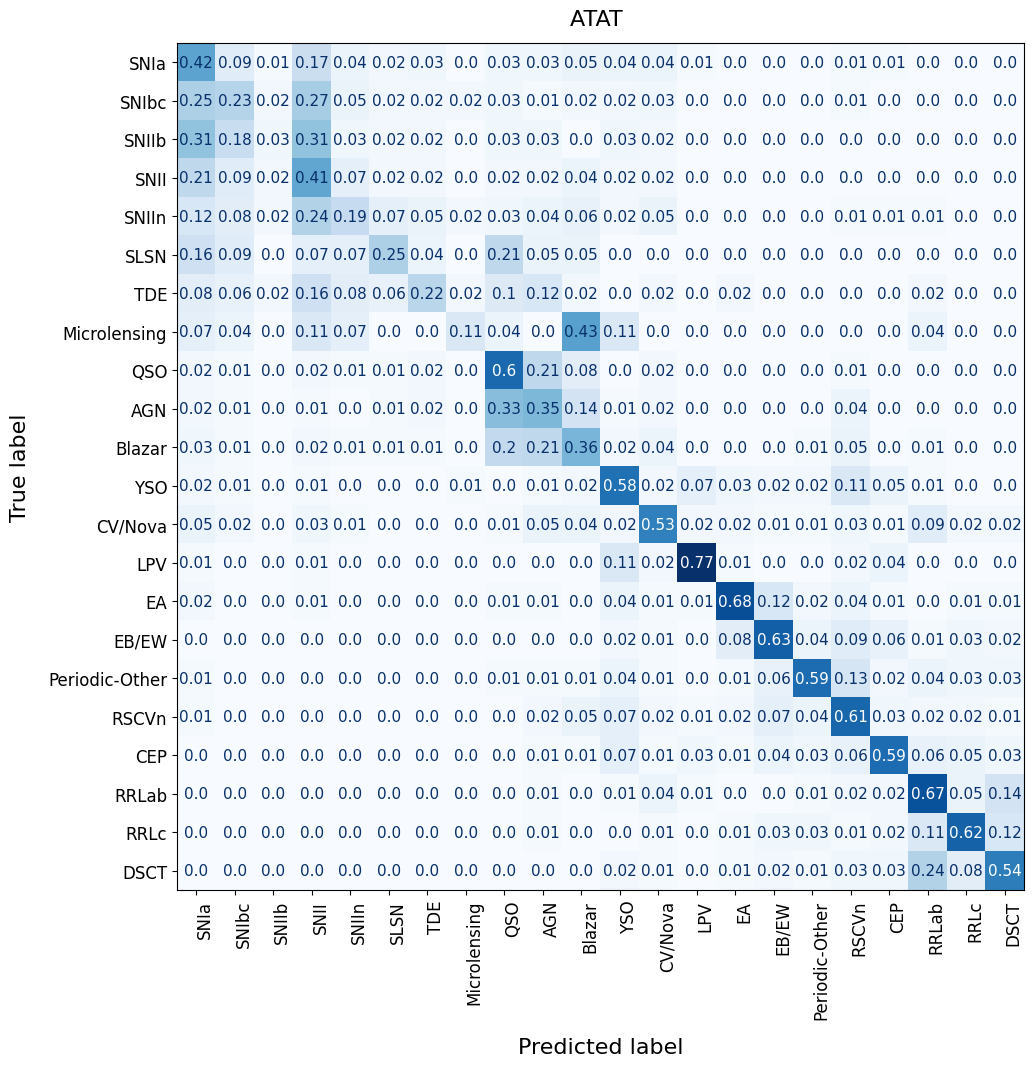

In [18]:
report_1 = test_1.classification_report(dataset, modality =  "LC")

In [40]:
import torchmetrics
test_2 = ReportClassification(
    path_to_training_dir='/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_new_window_dataset_v5_MLP_1E_trans/',
    path_to_dataset= 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5',
    #path_to_dataset= '/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5',
    model_class = LightCurveTransformer,
    custom_parse_key_str= '',
    model_type = 'lc',
    taxonomy = ZTF_TAXONOMY, #ELASTICC_TAXONOMY,
    device = 'cuda:2',
    seed = 0,
    figsize = (10,10),
    batch_size=128,
    umap_args={"n_neighbors": 15, "min_dist": 0.05, "metric": "euclidean"},
    marker_size = 6)

['/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_new_window_dataset_v5_MLP_1E_trans/classifier_ckpt_step=2449.ckpt']
using checkpoint 2449.ckpt


LC
<KeysViewHDF5 ['SNID', 'extracted_feat_1024', 'extracted_feat_128', 'extracted_feat_16', 'extracted_feat_2048', 'extracted_feat_256', 'extracted_feat_32', 'extracted_feat_512', 'extracted_feat_64', 'flux', 'flux_err', 'labels', 'mask', 'mask_detection', 'mask_photometry', 'metadata_feat', 'test', 'time', 'time_detection', 'time_photometry', 'training_0', 'validation_0']>


100%|██████████| 318/318 [00:05<00:00, 55.67it/s]


                precision    recall  f1-score   support

           AGN     0.4718    0.3975    0.4315      3288
           QSO     0.5950    0.5216    0.5559      3428
            EA     0.7599    0.6863    0.7212      3500
           YSO     0.5664    0.5797    0.5730      2715
          SNIa     0.4739    0.4094    0.4393      1639
       CV/Nova     0.5256    0.5071    0.5162      1617
          RRLc     0.7005    0.6807    0.6905      3439
         RSCVn     0.5441    0.5159    0.5296      2522
        Blazar     0.2686    0.3856    0.3167      1364
          SNII     0.3119    0.3865    0.3452       802
         EB/EW     0.6726    0.6781    0.6753      3635
           LPV     0.8572    0.7505    0.8003      3319
           CEP     0.6636    0.5855    0.6221      2871
         RRLab     0.7081    0.5734    0.6337      3507
Periodic-Other     0.3294    0.6065    0.4269       742
          DSCT     0.4046    0.6004    0.4834      1604
         SNIbc     0.1733    0.2780    0.2135  

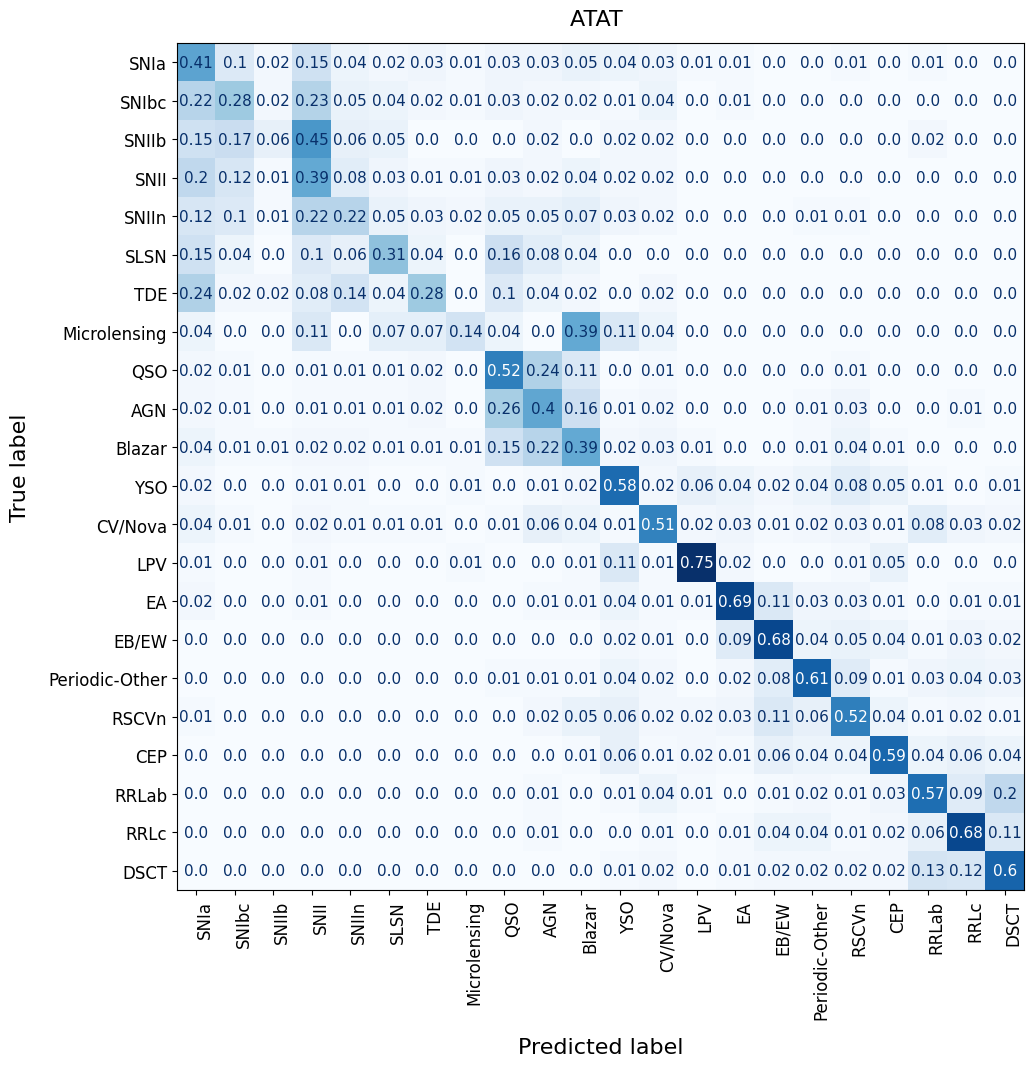

In [41]:
report_2 = test_2.classification_report(dataset, modality =  "LC")

AGN {'precision': 0.458628841607565, 'recall': 0.354014598540146, 'f1-score': 0.3995880535530381, 'support': 3288.0}
QSO {'precision': 0.5701559020044543, 'recall': 0.5974329054842473, 'f1-score': 0.5834757834757834, 'support': 3428.0}
EA {'precision': 0.8004718570947085, 'recall': 0.6785714285714286, 'f1-score': 0.7344982217411473, 'support': 3500.0}
YSO {'precision': 0.5535029627047752, 'recall': 0.5848987108655617, 'f1-score': 0.5687679083094556, 'support': 2715.0}
SNIa {'precision': 0.464524765729585, 'recall': 0.42342892007321536, 'f1-score': 0.44302585381423554, 'support': 1639.0}
CV/Nova {'precision': 0.5198776758409785, 'recall': 0.525664811379097, 'f1-score': 0.5227552275522755, 'support': 1617.0}
RRLc {'precision': 0.7483397413491786, 'recall': 0.6225646990404188, 'f1-score': 0.6796825396825397, 'support': 3439.0}
RSCVn {'precision': 0.5054116103640538, 'recall': 0.6110229976209358, 'f1-score': 0.553222042721235, 'support': 2522.0}
Blazar {'precision': 0.29115407147041594, 'r

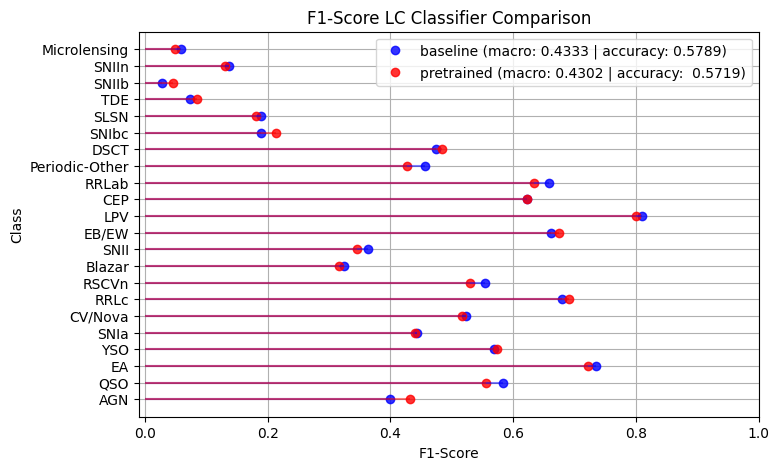

In [42]:
import pandas as pd
import numpy as np
def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in d1.items():
        print(key,value)
        if key in ZTF_TAXONOMY().keys():
        
            f1_baseline.append(value['f1-score'])
        
    df_1 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_baseline })
    ordered_df_1 = df_1 #.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)

    for key,value in d2.items():
        if key in (ZTF_TAXONOMY().keys()):
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_finetune})
    ordered_df_2 = df_2 #.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['1','2'])
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(-0.01,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )

    plt.legend([f'baseline (macro: {np.round(d1['macro avg']['f1-score'],4)} | accuracy: {np.round(d1['accuracy'],4)})',
                f'pretrained (macro: {np.round(d2['macro avg']['f1-score'],4)} | accuracy:  {np.round(d2['accuracy'],4)})'])
    # Show the plot
    plt.show()
compare_models(report_1,report_2)

In [43]:
transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}

periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}

In [44]:
import numpy as np
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in report_1.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))


group eval:
trans 0.18524862720114071
stoch 0.47965200871031505
per 0.6279938888120704


In [45]:
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in report_2.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')    
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

group eval:
trans 0.18604054466278167
stoch 0.4786509889252062
per 0.6203495987846739


In [46]:
adfadf

NameError: name 'adfadf' is not defined

In [ ]:
def early_as(path_1:str, before_time:int,supress_cm = False,supress_dict = False):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    model = LightCurveClassifier(**args) 
    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 
            #print(key)
            if 'project' in key:
                continue
            if 'model' in key:
                od_atat[key.replace("model.", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 256

    pl_datal = LitData(**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = 'cuda:2')  

    for b1 in tqdm(dataloader):

        #print(b1.keys())
        b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
        #print(b1['time'].shape,b1['mask'].shape)
        #b1['data'][:,before_time:,:] = 0
        #b1['time'][:,before_time:,:] = 0
        #b1['mask'] = (b1['data'] !=0)
        mask = torch.ones_like(b1['mask'])
        #mask[before_time:,:] = 0 
        #b1['mask'] = b1['mask'] * mask
        lc_emb = model(**b1)  
        t = b1['labels']
        preds_out = (
            np.concatenate([preds_out, torch.argmax(lc_emb, axis=1).detach().cpu().numpy()])
            if preds_out is not None
            else torch.argmax(lc_emb, axis=1).cpu().detach().numpy()
        )
        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.detach().cpu().numpy()
        )
    results = preds_out
    classification = classification_report(target, results, target_names=list(DICT.keys()),digits = 4)
    data_dict =  classification_report(target, results, target_names=list(DICT.keys()),digits = 4, output_dict=True)    
    if supress_dict == 0:
        print(classification)
    if supress_cm == 0:        
        from src.utils.plottinglib import elasticc_confusion_matrix
        out_metrics_balto = classification_report(
            target, results, target_names=list(DICT.keys()), output_dict=True
        )["macro avg"]
        template_balto = ""
        for key in out_metrics_balto.keys():
            template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
        fig, axes = plt.subplots(1, 1, figsize=(12, 12))
        elasticc_confusion_matrix(
            y_true=np.array(target).astype(int),
            y_pred=np.array(results).astype(int),
            classes= np.array(list(DICT.keys())),
            ax=axes,
            normalize=True,
            
            title=f" FClassifier Results [TEST] \n\n {template_balto}",
        )
        plt.show()
    
    return data_dict

In [ ]:
data_dict_1['macro avg']['f1-score']

In [ ]:
e_times = [10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,200]
macro_f1_eval_times = {'d1':[],'d2':[]}
for eval_time in e_times:
    data_dict_1 = early_as(path_1, before_time = eval_time,supress_cm=True,supress_dict=True)
    data_dict_2 = early_as(path_2, before_time = eval_time,supress_cm=True,supress_dict=True)
    macro_f1_eval_times['d1'].append(data_dict_1['macro avg']['f1-score'])
    macro_f1_eval_times['d2'].append(data_dict_2['macro avg']['f1-score'])
    compare_models(data_dict_1,data_dict_2,eval_time)

data_dict_1 = produce_report(path_1)
data_dict_2 = produce_report(path_2) 

In [ ]:
import seaborn as sns

sns.lineplot(macro_f1_eval_times[::-1])
#plt.legend(['baseline','pretrained'])

plt.title('F1-score for ')
plt.xticks(list(range(len(e_times))),[str(time) for time in e_times])
plt.xlabel('Max Evaluated Time')
plt.ylabel('F1-score')
plt.grid('on')

modl is not sample dependent